# Alternative Implementations in scikit-learn for Large Datasets

Scikit-learn provides highly optimized implementations for training linear classifiers, which are essential when working with large-scale data.

### 1. High-Performance C/C++ Backends (In-Memory)
Standard scikit-learn classes often utilize extremely fast C/C++ libraries under the hood, making them much quicker than native Python implementations:
* **Logistic Regression:** The `LogisticRegression` class can leverage the **LIBLINEAR** library by setting the parameter `solver='liblinear'`.
* **Support Vector Machines:** The `SVC` class utilizes the equivalent **LIBSVM** library.

### 2. Online Learning with SGDClassifier (Out-of-Core)
If your dataset is **too large to fit into your computer's memory (RAM)**, the standard in-memory algorithms will fail. To solve this, scikit-learn offers the `SGDClassifier` class.
* **Batch Processing:** It supports online learning, allowing you to train the model on smaller chunks of data at a time using the `partial_fit` method.
* **Versatility:** Based on Stochastic Gradient Descent (SGD), you can configure this single class to mimic different standard classifiers simply by changing the `loss` parameter.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
X_combined_std, y_combined, X_train_std, X_test_std, y_train, y_test = data_reader()

In [33]:
from sklearn.linear_model import SGDClassifier

In [34]:
ppn = SGDClassifier(loss='perceptron')
ppn.fit(X_train_std, y_train)

SGDClassifier(loss='perceptron')

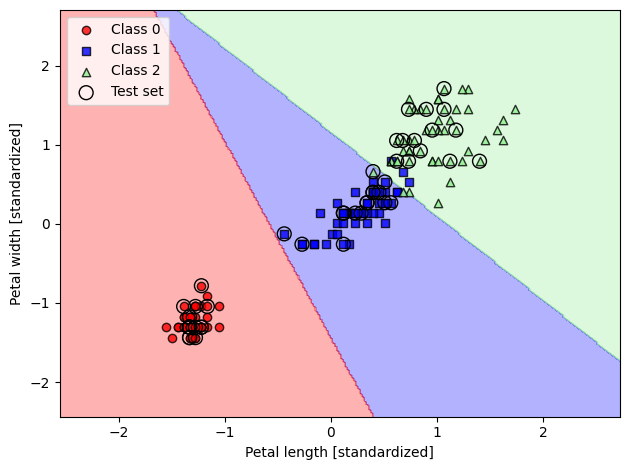

In [35]:
plot_decision_regions(X_combined_std,
                      y_combined,
                      classifier=ppn,
                      test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [36]:
lr = SGDClassifier(loss='log_loss')
lr.fit(X_train_std, y_train)

SGDClassifier(loss='log_loss')

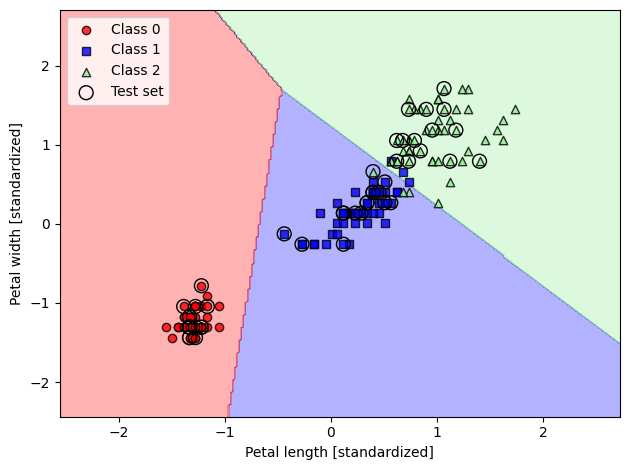

In [37]:
plot_decision_regions(X_combined_std,
                      y_combined,
                      classifier=lr,
                      test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
svm = SGDClassifier(loss='hinge')
svm.fit(X_train_std, y_train)

SGDClassifier()

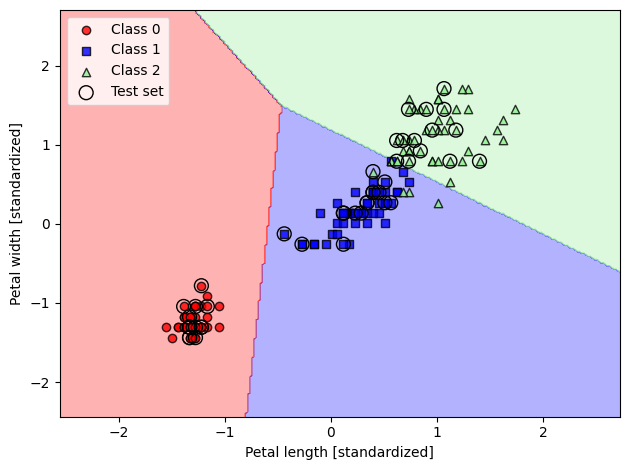

In [39]:
plot_decision_regions(X_combined_std,
                      y_combined,
                      classifier=svm,
                      test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()